In [14]:
from src import *

In [147]:
for d in np.arange(0, 101, 2):
    c1 = LoadEstimates(f'data_/spade_3px_f0.2_d0.npz').cropped_data
    c2 = np.load(f'MLEtest/spade_3px_f0.2_d0.npz', allow_pickle=True)['cropped_data']
    print(np.all(c1 == c2))

FileNotFoundError: [Errno 2] No such file or directory: 'data_/spade_3px_f0.2_d0.npz'

True

In [130]:
d0 = LoadEstimates('data/spade_5px_f0.2_d0.npz')
pn = d0.photons
pn

array(72.336847)

In [135]:
for file in glob('data/*'):
    c = LoadEstimates(file)
    if c.metadata.measurement == 'SPADE' and c.metadata.pwm_duty != 0:
        c.photons = pn
        c.background = (qCMOS.convert2photons(c.cropped_data).sum(-1).mean() - c.photons) / c.cropped_data.shape[-1]
        c = c.est()
    elif c.metadata.measurement =='DI':
        c.background = c.background / c.cropped_data.shape[-1]

    c.savez('data_/')

In [132]:
spade_bg2 = []
di_bg2 = []
for d in np.arange(0, 101, 2):
    file = np.load(f'MLEtest/spade_5px_f0.2_d{d}.npz', allow_pickle=True)
    spade_bg2.append(qCMOS.convert2photons(file['background']).mean())

    file = np.load(f'MLEtest/di_5px_f0.2_d{d}.npz', allow_pickle=True)
    di_bg2.append(qCMOS.convert2photons(file['background']).mean())

In [136]:
spade_bg = []
di_bg = []
for f in glob('data_/*_f0.2_*'):
    c = LoadEstimates(f)
    if c.metadata.measurement == 'SPADE':
        spade_bg.append(c.background)
    elif c.metadata.measurement == 'DI':
        di_bg.append(c.background)

In [125]:
data = np.load('MLEtest/spade_5px_f0.2_d0.npz', allow_pickle=True)['cropped_data']
photons_ =  qCMOS.convert2photons(data).sum(-1).mean()
bg = (qCMOS.convert2photons(data).sum(-1).mean() - photons_) / data.shape[-1]

In [126]:

c = Estimates(MetaData('SPADE', 0.2, 5*DMD.PIXEL_SIZE/2), data, bg, photons_).est()

c

metadata: measurement: SPADE
ground_truth: 0.2
amplitude: 48.436814511278506
pwm_duty: 0
cropped_data: [[[495. 532.]
  [472. 447.]
  [523. 438.]
  ...
  [615. 492.]
  [806. 263.]
  [849. 248.]]

 [[505. 700.]
  [439. 528.]
  [457. 587.]
  ...
  [466. 518.]
  [666. 334.]
  [721. 298.]]

 [[489. 480.]
  [436. 473.]
  [503. 533.]
  ...
  [514. 600.]
  [786. 276.]
  [678. 315.]]

 ...

 [[420. 502.]
  [406. 488.]
  [529. 617.]
  ...
  [452. 530.]
  [826. 324.]
  [696. 333.]]

 [[643. 550.]
  [472. 471.]
  [647. 569.]
  ...
  [494. 501.]
  [949. 321.]
  [961. 282.]]

 [[463. 602.]
  [451. 501.]
  [515. 553.]
  ...
  [533. 586.]
  [797. 300.]
  [830. 294.]]]
background: 0.0
photons: 72.33684699999999
time_domain: [[ 54.52026602  43.47246671  32.74009899 ...  30.3797884  -56.34310775
  -67.16762044]
 [ 73.7288348   64.70524237  69.44499544 ...  57.62630488 -14.03757929
  -33.30599861]
 [ 46.80753861  55.93396898  53.29801092 ...  60.88828953 -48.1206992
  -22.45805898]
 ...
 [ 64.71803074  65

In [122]:
LoadEstimates(r'data_/spade_5px_f0.2_d0.npz').photons

array(53.290259)

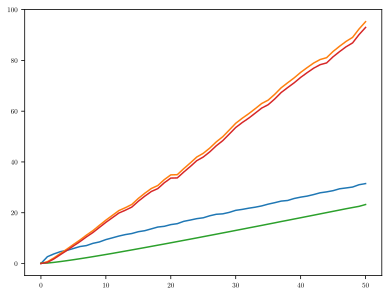

In [137]:
plt.plot(np.sort(np.array(spade_bg)))
plt.plot(np.sort(np.array(di_bg)))

plt.plot(np.sort(np.array(spade_bg2)))
plt.plot(np.sort(np.array(di_bg2)))


In [22]:
c1 = '#1f77b4'
c2 = '#2ca02c'

red = '#d62728'
width = 8.5

In [45]:
# def read_noisy_est():
spade_mean, spade_var, spade_b = [], [], []
di_mean, di_var, di_b = [], [], []
for d in np.arange(0, 101, 2):
    spade_c = LoadEstimates(rf'data/spade_5px_f0.2_d{d}.npz')
    di_c = LoadEstimates(rf'data/di_5px_f0.2_d{d}.npz')

    spade_mean.append(spade_c.estimates_b.mean())
    spade_var.append(spade_c.estimates_b.var(ddof=1))
    spade_b.append(spade_c.background / 2 / spade_c.photons)

    di_mean.append(di_c.estimates_b.mean())
    di_var.append(di_c.estimates_b.var(ddof=1))
    di_b.append(di_c.background / 200 / spade_c.photons)

#     return np.array(spade_mean), np.array(spade_var), np.array(spade_b), \
#            np.array(di_mean), np.array(di_var), np.array(di_b)

# spade_mean, di_mean, spade_var, di_var, spade_b, di_b = read_noisy_est()

b_axis = np.linspace(1e-10, 0.2, 1000)
spade_crb = [SPADE.CRB(b, 5*DMD.PIXEL_SIZE/2, 0.2)[1, 1] for b in b_axis]
di_crb = [DI.CRB(b, 5*DMD.PIXEL_SIZE/2, 0.2)[1, 1] for b in b_axis]

In [77]:
spade_c = LoadEstimates(rf'data/spade_5px_f0.2_d{100}.npz')
(qCMOS.convert2photons(spade_c.cropped_data).mean() * 2 - spade_c.photons) / 2 / spade_c.photons

0.7694553426734136

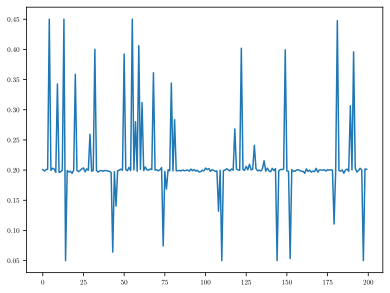

In [78]:
plt.plot(spade_c.estimates_b)

In [71]:
qCMOS.convert2photons(spade_c.cropped_data.sum(-1)).mean()

75.290215

In [65]:
di_c = LoadEstimates(rf'data/di_5px_f0.2_d{2}.npz')
(qCMOS.convert2photons(di_c.cropped_data).mean() * 200 - di_c.photons) / 200 / di_c.photons

0.0017659774968637207

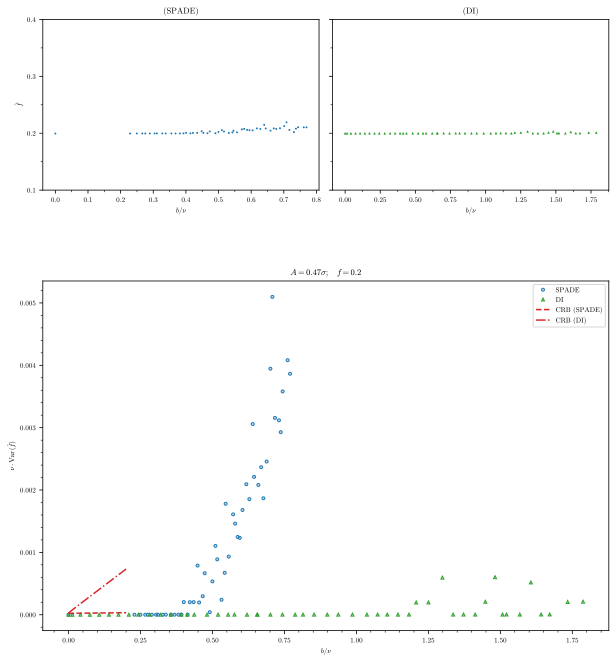

In [46]:
fig = plt.figure(figsize=(width, width*1.25))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax2.tick_params(axis='y', labelleft=False)

ax3 = fig.add_subplot(gs[1, :])

ax1.plot(spade_b, spade_mean, marker='o', linestyle='', markersize=1, 
         markeredgecolor=c1, markerfacecolor=c1)

ax2.plot(di_b, di_mean, marker='^', linestyle='', markersize=1, 
         markeredgecolor=c2, markerfacecolor=c2)

ax1.set_ylabel(r'$\hat f$')
ax1.set_yticks(np.linspace(0.1, 0.4, 4))

ax1.set_title('(SPADE)')
ax2.set_title('(DI)')

for ax_ in (ax1, ax2, ax3):
    ax_.set_box_aspect(0.618)
    # ax_.set_xlim(0, 0.2)
    ax_.set_xlabel(r'$b/\nu$')
    
    if not ax_ == ax3:
        # ax_.set_ylim(0.1, 0.4)
        ax_.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax_.yaxis.set_minor_locator(AutoMinorLocator(2))

    else:
        # ax_.set_ylim(0, 2e-4)
        ax_.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_.yaxis.set_minor_locator(AutoMinorLocator(5))



ax3.plot(spade_b, spade_var, color=c1, marker='o', 
         linestyle='', markersize=3, 
         markeredgecolor=c1, markerfacecolor=(c1, 0.3),
         label='SPADE')

ax3.plot(di_b, di_var, color=c2, marker='^', 
         linestyle='', markersize=3, 
         markeredgecolor=c2, markerfacecolor=(c2, 0.3),
         label='DI')

ax3.plot(b_axis, spade_crb, linestyle='--', color=red, label='CRB (SPADE)')
ax3.plot(b_axis, di_crb, linestyle='-.', color=red, label='CRB (DI)')

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))

# ax3.yaxis.set_major_formatter(formatter)
# ax3.set_xticks(np.linspace(0, 0.2, 5))
# ax3.set_yticks(np.arange(0, 2.001, 0.5) * 1e-4)

ax3.set_title(r'$A=0.47\sigma;\quad f=0.2$')
ax3.set_ylabel(r'$\nu\cdot{\rm Var\,}(\hat f)$')
ax3.legend(loc='best')

plt.tight_layout()
# plt.savefig('noisy.pdf')
plt.show()
